# 🛒 Retail Sales Performance Analysis

### Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

### Project Objective
The objective of this project is to analyze retail sales data, identify sales trends, evaluate product performance, and generate business insights to support data-driven decision-making.

### Dataset Information
- Total Records: 10,557
- Records After Cleaning: 10,494
- Features: Order ID, Product Name, Category, Quantity, Unit Price, Revenue, Date, and Region.

## Step 1 - Import Libraries and Load Data

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the retail dataset in pandas dataframe
df = pd.read_csv('retail_sales.csv')

print(df.head())       # Disply the first 5 rows to preview the data
print(df.shape)        # Show the number of rows and columns in the dataset
print(df.dtypes)       # Display the datatype of each column

   order_id    product_name   category  quantity  unit_price    revenue  \
0      5032        Sofa Set  Furniture        10    23896.97  238969.70   
1      2724  Cooking Oil 1L    Grocery         3      176.59     529.77   
2      9162        Sneakers   Clothing         2     1871.86    3743.72   
3      2436    Dining Table  Furniture         1    11518.93   11518.93   
4      7410    Formal Shirt   Clothing         3      928.59    2785.77   

         date region  
0  2024-06-14   West  
1  2024-03-06  North  
2  2024-11-13   East  
3  2024-03-19  North  
4  2024-09-20   East  
(10557, 8)
order_id          int64
product_name        str
category            str
quantity          int64
unit_price      float64
revenue         float64
date                str
region              str
dtype: object


## Step 2 - Data Cleaning

In [24]:
# Check for the missing values
print(df.isnull().sum())

order_id         0
product_name     0
category         0
quantity         0
unit_price       0
revenue         47
date             0
region           0
dtype: int64


In [25]:
# Fill missing revenue with quatity * unit price
df['revenue'] = df['revenue'].fillna(df['quantity'] * df['unit_price'])

# Remove duplicate rows
df.drop_duplicates(inplace = True)

# Convert date column from string to datetime
df['date'] = pd.to_datetime(df['date'])

# Extract month and quarter from date
df['month'] = df['date'].dt.month
df['quarter'] = df['date'].dt.quarter

print("Cleaned! Total Rows:", len(df))

Cleaned! Total Rows: 10494


## Step 3 - Feature Engineering with NumPy

In [40]:
# Assume the product cost is 60% of the selling price
df['cost'] = df['unit_price'] * 0.60

# Calculate profit earned on each transaction
# Profit = Revenue - Total Cost
df['profit'] = df['revenue'] - (df['quantity'] * df['cost'])

# Calculate profit margin (%) for each sale
# Profit Margin = (Profit / Revenue) × 100
df['profit_margin'] = np.round((df['profit'] / df['revenue']) * 100, 2)

# Calculate average revenue generated per unit sold
df['revenue_per_unit'] = np.round((df['revenue'] / df['quantity']), 2)

# Display the newly created columns for the first 3 records
print(df[['product_name', 'revenue', 'profit', 'profit_margin']].head(3))

     product_name    revenue     profit  profit_margin
0        Sofa Set  238969.70  95587.880           40.0
1  Cooking Oil 1L     529.77    211.908           40.0
2        Sneakers    3743.72   1497.488           40.0


## Step 4 — Exploratory Data Analysis (EDA)

In [41]:
# Group the data by product category and calculate the total revenue for each category
# Sort the categories in descending order to identify the highest revenue-generating category
category_revenue = df.groupby('category')['revenue'].sum().sort_values(ascending=False)

# Display total revenue generated by each product category
print(category_revenue)

category
Electronics    2.076614e+08
Furniture      1.054914e+08
Clothing       1.183100e+07
Grocery        1.381845e+06
Name: revenue, dtype: float64


In [42]:
# Group the data by month and calculate the total revenue for each month
monthly_revenue = df.groupby('month')['revenue'].sum()

# Display the monthly revenue trend
print(monthly_revenue)

month
1     15490137.93
2     20515150.83
3     24577180.90
4     20598643.85
5     22424274.99
6     24960427.94
7     25561315.22
8     27982259.38
9     22535117.98
10    35750369.42
11    40684095.30
12    45286703.13
Name: revenue, dtype: float64


In [30]:
top_products = df.groupby('product_name')['revenue'].sum().sort_values(ascending = False).head(5)
print(top_products)

product_name
Laptop Pro      76942147.61
LED TV 55"      66797292.74
Smartphone X    53599828.04
Sofa Set        46891944.36
Bed Frame       25461027.17
Name: revenue, dtype: float64


In [31]:
Total_rev = df['revenue'].sum()
print(Total_rev)

326365676.87


## Step 5 — Data Visualisation

###  Bar Chart - Revenue by Category

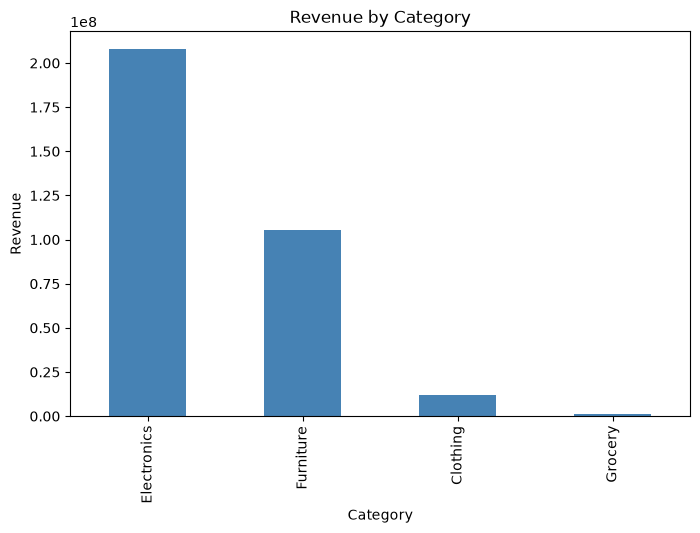

In [43]:
# Create a bar chart to compare total revenue across different product categories
category_revenue.plot(kind="bar", figsize=(8,5), color="steelblue")

# Add a title to the chart
plt.title("Revenue by Category")

# Label the x-axis
plt.xlabel("Category")

# Label the y-axis
plt.ylabel("Revenue")

# Display the chart
plt.show()

#### Observation
- Electronics generated the highest total revenue.
- Furniture was the second highest revenue-generating category.
- Grocery contributed the least revenue.

#### Business Impact
- Electronics is the company's primary source of revenue.
- Higher demand indicates customers prefer electronic products.

#### Recommendation
- Increase Electronics inventory to avoid stock shortages.
- Focus marketing campaigns on high-performing categories.
- Improve promotions for low-performing categories like Grocery.

#### Key Takeaway
Electronics is the top-performing category and should be the primary focus for business growth.

***

### Monthly Revenue Line Chart

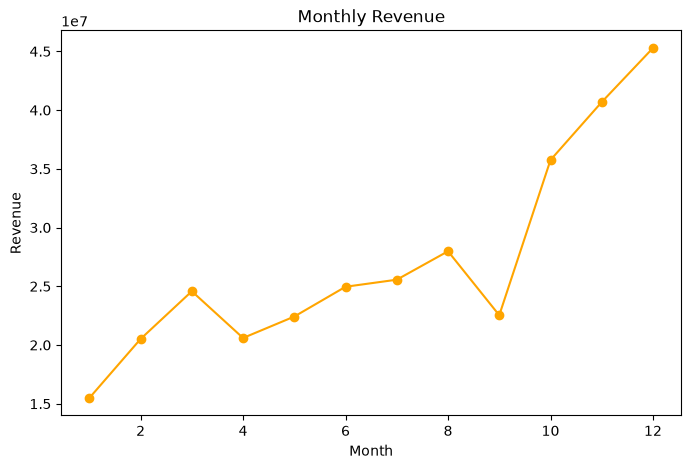

In [44]:
# Create a line chart to visualize the monthly revenue trend
monthly_revenue.plot(kind="line", marker="o", figsize=(8,5), color="orange")

# Add a title to the chart
plt.title("Monthly Revenue")

# Label the x-axis
plt.xlabel("Month")

# Label the y-axis
plt.ylabel("Revenue")

# Display the chart
plt.show()

#### Observation
- Revenue increased gradually throughout the year.
- December recorded the highest revenue.
- January recorded the lowest revenue.
- Quarter 4 (October–December) showed the strongest sales performance.

#### Business Impact
- Sales increase significantly during the festive season.
- The business experiences seasonal demand in Q4.

#### Recommendation
- Increase inventory before Quarter 4.
- Plan marketing campaigns before the festive season.
- Offer discounts during January to improve sales.

#### Key Takeaway
Quarter 4 is the company's peak sales period, while January is the slowest month.

***

### Heatmap

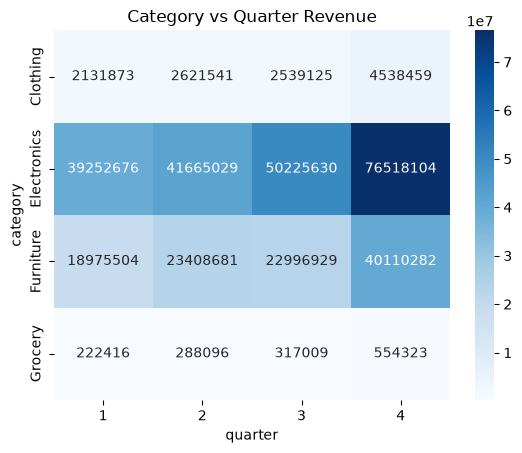

In [45]:
# Create a pivot table to summarize total revenue by category and quarter
pivot = df.pivot_table(
    values="revenue",
    index="category",
    columns="quarter",
    aggfunc="sum"
)

# Create a heatmap to visualize revenue across categories and quarters
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="Blues")

# Add a title to the heatmap
plt.title("Category vs Quarter Revenue")

# Display the heatmap
plt.show()

#### Observation
- Electronics generated the highest revenue across all quarters.
- Quarter 4 showed the highest overall revenue.
- Grocery sales remained relatively stable throughout the year.

#### Business Impact
- Electronics is the strongest-performing category.
- Quarter 4 is the most profitable period for the business.

#### Recommendation
- Increase Electronics stock before Quarter 4.
- Allocate a higher marketing budget during Q4.
- Continue maintaining Grocery inventory because demand is consistent.

#### Key Takeaway
Electronics dominates sales, especially during Quarter 4.

---

# 📌 Project Summary

## Objective
Analyze retail sales data to identify revenue trends, top-performing products, and business opportunities.

## Key Findings
- Total Revenue: ₹326.37 Million
- Electronics generated the highest revenue.
- Laptop Pro was the highest revenue-generating product.
- December recorded the highest monthly revenue.
- Quarter 4 (October–December) was the strongest sales period.
- Electronics contributed approximately 63.6% of the total revenue.

## Business Recommendations
- Increase Electronics inventory before Quarter 4.
- Launch promotional campaigns during January to improve sales.
- Focus marketing efforts on top-selling products.
- Improve sales strategies for lower-performing categories.

## Conclusion
This project demonstrates how Python, Pandas, NumPy, Matplotlib, and Seaborn can be used to clean, analyze, and 
visualize retail sales data. The insights generated from this analysis can support better business decisions related to 
inventory management, sales planning, and marketing strategies.